In [4]:
# 노트북에서 상위 폴더의 모듈을 import하기 위한 경로 설정
import sys, os
sys.path.append(os.path.abspath(".."))   # notebooks/의 상위 = 프로젝트 루트

import torch
print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())

torch: 2.6.0+cu124
cuda: True


In [2]:
from utils.data import get_dataloaders
from utils.train import fit
from utils.metrics import collect_predictions, print_metrics_report, get_confusion_matrix
from utils.visualize import (
    plot_learning_curve,
    plot_confusion_matrix,
    extract_features,
    plot_tsne,
)
from models.mlp import MLP

print("모든 모듈 import 성공")

모든 모듈 import 성공


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# 데이터 로딩 (train/val/test) — data_dir도 루트 기준으로
train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=128,
    data_dir="../data"     # notebooks/의 상위 = 프로젝트 루트의 data/
)

# MLP 학습 (개발 단계니 15 epoch로 빠르게)
model = MLP()
history, best_epoch, test_result = fit(
    model, train_loader, val_loader, test_loader,
    epochs=15, device=device,
    save_path="../results/mlp_best.pth"   # 루트 기준
)

device: cuda
Epoch  1/15 | train_loss 0.2832 acc 0.9156 | val_loss 0.1502 acc 0.9545  <- best
Epoch  2/15 | train_loss 0.1079 acc 0.9673 | val_loss 0.1189 acc 0.9647  <- best
Epoch  3/15 | train_loss 0.0736 acc 0.9769 | val_loss 0.0899 acc 0.9732  <- best
Epoch  4/15 | train_loss 0.0527 acc 0.9834 | val_loss 0.0836 acc 0.9742  <- best
Epoch  5/15 | train_loss 0.0424 acc 0.9862 | val_loss 0.0935 acc 0.9723
Epoch  6/15 | train_loss 0.0321 acc 0.9897 | val_loss 0.0893 acc 0.9763
Epoch  7/15 | train_loss 0.0275 acc 0.9911 | val_loss 0.0994 acc 0.9718
Epoch  8/15 | train_loss 0.0254 acc 0.9914 | val_loss 0.0907 acc 0.9762
Epoch  9/15 | train_loss 0.0208 acc 0.9929 | val_loss 0.0902 acc 0.9765
Epoch 10/15 | train_loss 0.0176 acc 0.9940 | val_loss 0.1051 acc 0.9732
Epoch 11/15 | train_loss 0.0166 acc 0.9941 | val_loss 0.0974 acc 0.9763
Epoch 12/15 | train_loss 0.0144 acc 0.9949 | val_loss 0.1010 acc 0.9773
Epoch 13/15 | train_loss 0.0205 acc 0.9928 | val_loss 0.0897 acc 0.9778
Epoch 14/15 | t

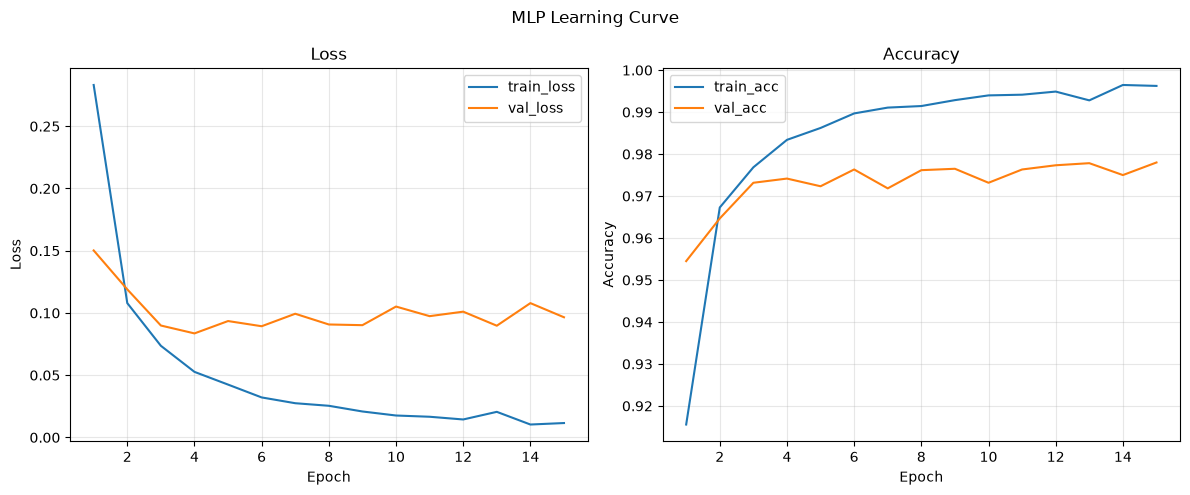

In [4]:
plot_learning_curve(history, title="MLP Learning Curve")

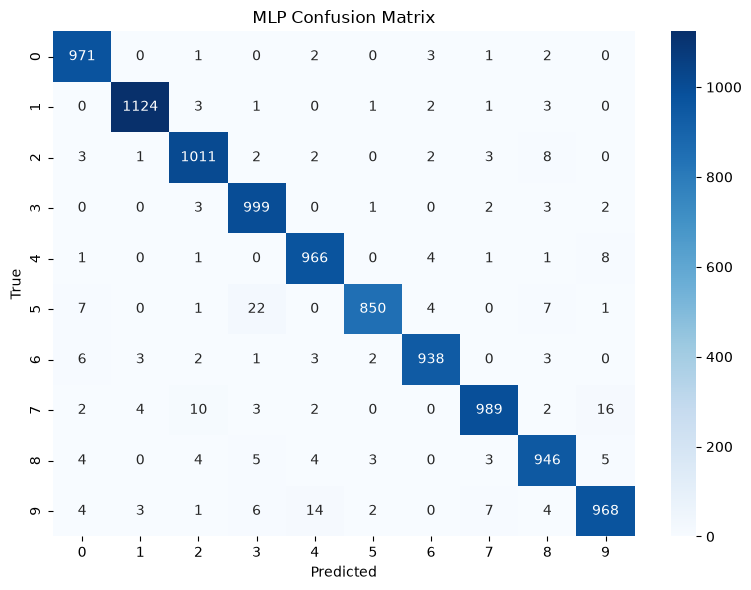

In [5]:
# best model로 test set 예측 수집
y_true, y_pred = collect_predictions(model, test_loader, device)

# confusion matrix heatmap (개수 버전)
plot_confusion_matrix(y_true, y_pred, title="MLP Confusion Matrix")

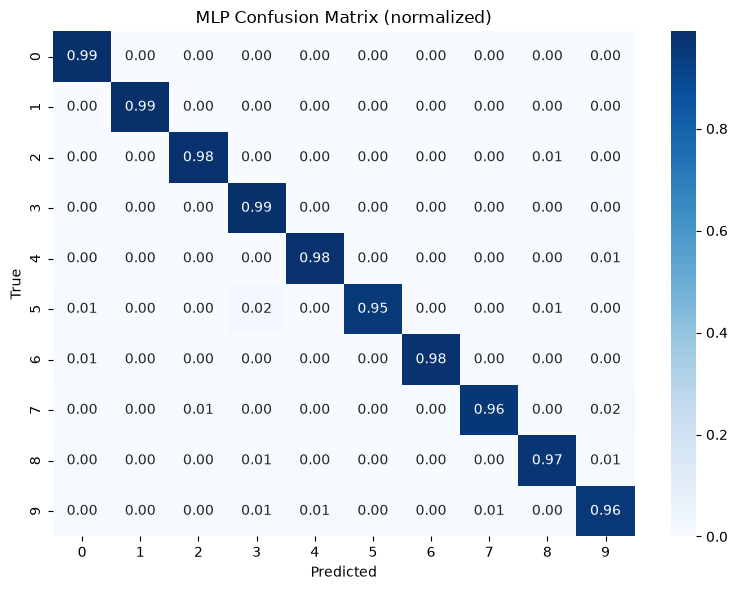

In [6]:
plot_confusion_matrix(y_true, y_pred, title="MLP Confusion Matrix (normalized)", normalize=True)

feature shape: (2000, 128)


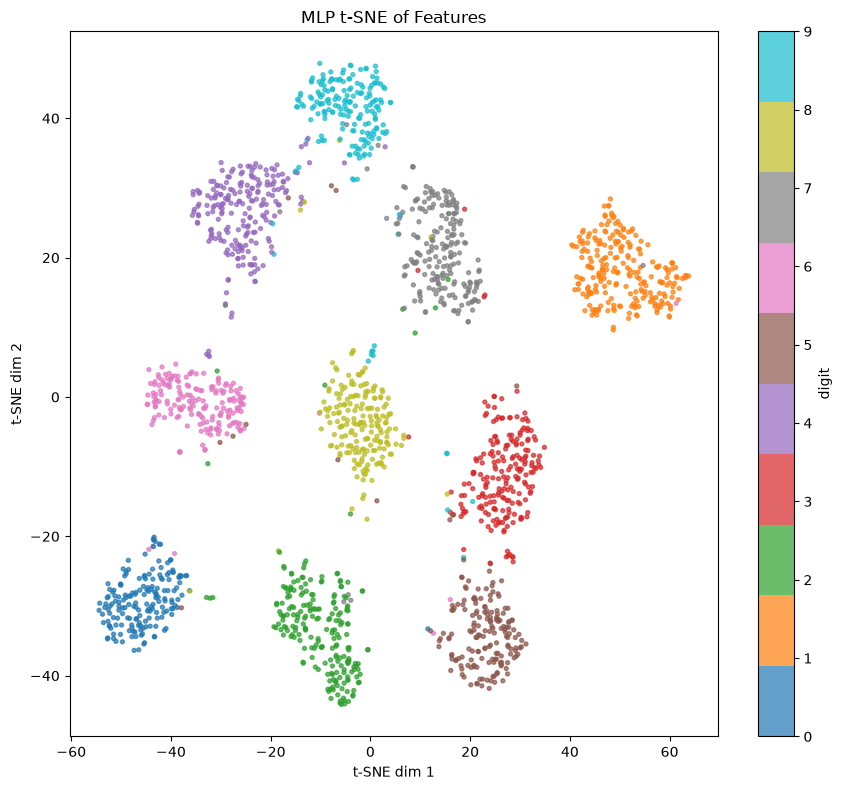

In [7]:
# penultimate feature 추출 (t-SNE는 느리니 2000개만)
features, labels = extract_features(model, test_loader, device, max_samples=2000)
print("feature shape:", features.shape)   # (2000, 128)

# t-SNE로 2D 투영해서 그리기
plot_tsne(features, labels, title="MLP t-SNE of Features")

In [8]:
from models.cnn import CNN

# CNN 학습 (MLP와 동일 조건: 15 epoch, 같은 데이터)
cnn_model = CNN()
cnn_history, cnn_best_epoch, cnn_test_result = fit(
    cnn_model, train_loader, val_loader, test_loader,
    epochs=15, device=device,
    save_path="../results/cnn_best.pth"
)

Epoch  1/15 | train_loss 0.1743 acc 0.9471 | val_loss 0.0675 acc 0.9795  <- best
Epoch  2/15 | train_loss 0.0504 acc 0.9849 | val_loss 0.0516 acc 0.9855  <- best
Epoch  3/15 | train_loss 0.0343 acc 0.9895 | val_loss 0.0380 acc 0.9870  <- best
Epoch  4/15 | train_loss 0.0233 acc 0.9929 | val_loss 0.0404 acc 0.9877
Epoch  5/15 | train_loss 0.0188 acc 0.9940 | val_loss 0.0478 acc 0.9860
Epoch  6/15 | train_loss 0.0180 acc 0.9944 | val_loss 0.0362 acc 0.9898  <- best
Epoch  7/15 | train_loss 0.0117 acc 0.9964 | val_loss 0.0417 acc 0.9887
Epoch  8/15 | train_loss 0.0096 acc 0.9968 | val_loss 0.0426 acc 0.9878
Epoch  9/15 | train_loss 0.0091 acc 0.9971 | val_loss 0.0453 acc 0.9883
Epoch 10/15 | train_loss 0.0064 acc 0.9978 | val_loss 0.0522 acc 0.9872
Epoch 11/15 | train_loss 0.0087 acc 0.9969 | val_loss 0.0538 acc 0.9868
Epoch 12/15 | train_loss 0.0069 acc 0.9977 | val_loss 0.0670 acc 0.9853
Epoch 13/15 | train_loss 0.0055 acc 0.9983 | val_loss 0.0511 acc 0.9887
Epoch 14/15 | train_loss 0.0

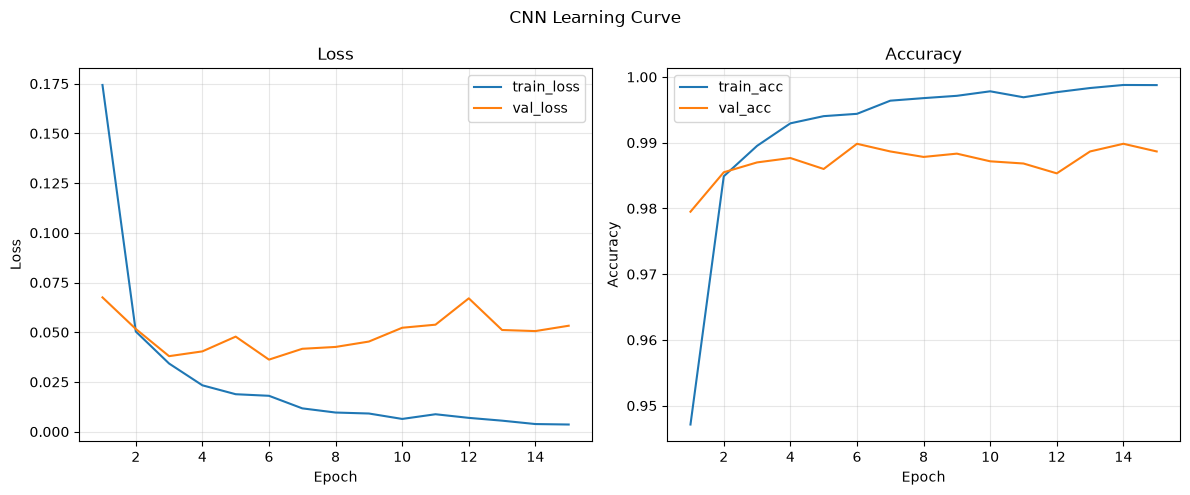

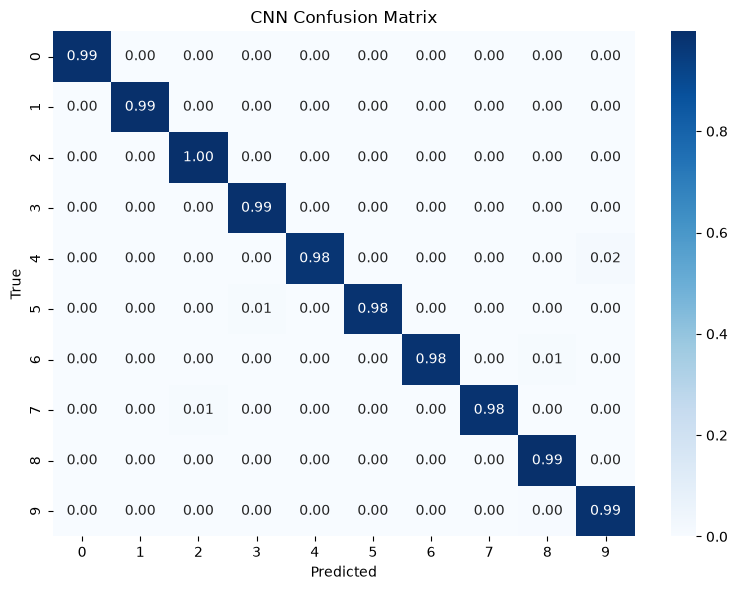

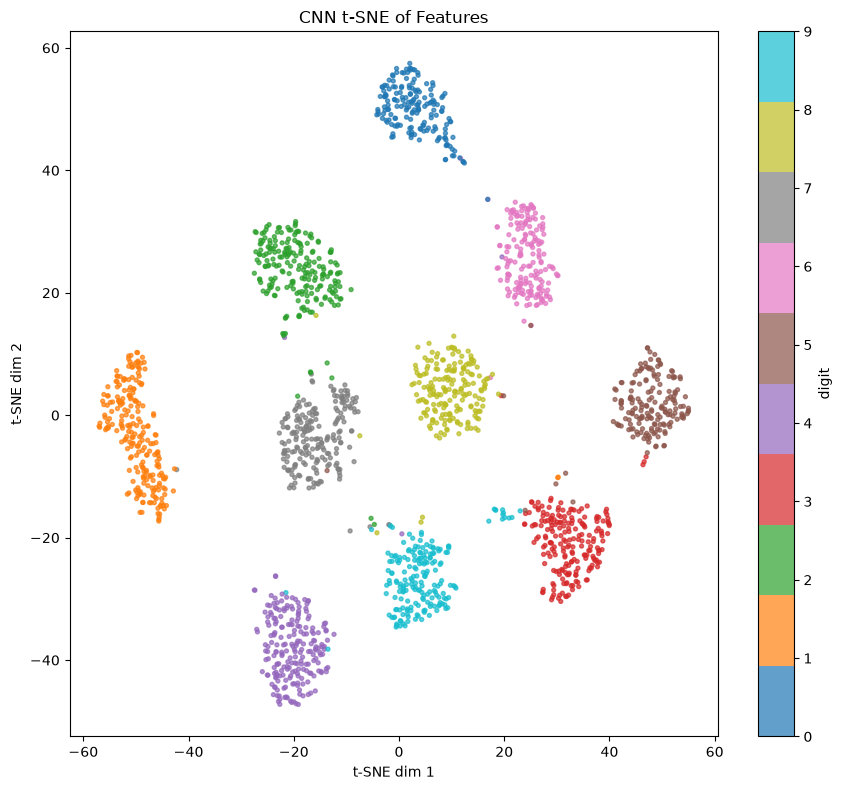

In [9]:
# 1) CNN learning curve
plot_learning_curve(cnn_history, title="CNN Learning Curve")

# 2) CNN confusion matrix
cnn_y_true, cnn_y_pred = collect_predictions(cnn_model, test_loader, device)
plot_confusion_matrix(cnn_y_true, cnn_y_pred, title="CNN Confusion Matrix", normalize=True)

# 3) CNN t-SNE
cnn_features, cnn_labels = extract_features(cnn_model, test_loader, device, max_samples=2000)
plot_tsne(cnn_features, cnn_labels, title="CNN t-SNE of Features")

In [10]:
import time
from models.rnn import RNN

# RNN 학습 (동일 조건: 15 epoch) + 시간 측정
rnn_model = RNN()

start = time.time()
rnn_history, rnn_best_epoch, rnn_test_result = fit(
    rnn_model, train_loader, val_loader, test_loader,
    epochs=15, device=device,
    save_path="../results/rnn_best.pth"
)
rnn_time = time.time() - start
print(f"\n>> RNN 총 학습 시간: {rnn_time:.1f}초 ({rnn_time/15:.1f}초/epoch)")

Epoch  1/15 | train_loss 0.4514 acc 0.8526 | val_loss 0.1364 acc 0.9613  <- best
Epoch  2/15 | train_loss 0.0983 acc 0.9712 | val_loss 0.0905 acc 0.9740  <- best
Epoch  3/15 | train_loss 0.0688 acc 0.9794 | val_loss 0.0737 acc 0.9802  <- best
Epoch  4/15 | train_loss 0.0507 acc 0.9845 | val_loss 0.0585 acc 0.9830  <- best
Epoch  5/15 | train_loss 0.0402 acc 0.9874 | val_loss 0.0634 acc 0.9825
Epoch  6/15 | train_loss 0.0346 acc 0.9897 | val_loss 0.0480 acc 0.9870  <- best
Epoch  7/15 | train_loss 0.0303 acc 0.9907 | val_loss 0.0546 acc 0.9845
Epoch  8/15 | train_loss 0.0271 acc 0.9916 | val_loss 0.0501 acc 0.9867
Epoch  9/15 | train_loss 0.0246 acc 0.9923 | val_loss 0.0546 acc 0.9845
Epoch 10/15 | train_loss 0.0210 acc 0.9933 | val_loss 0.0419 acc 0.9890  <- best
Epoch 11/15 | train_loss 0.0188 acc 0.9941 | val_loss 0.0402 acc 0.9863  <- best
Epoch 12/15 | train_loss 0.0184 acc 0.9942 | val_loss 0.0391 acc 0.9888  <- best
Epoch 13/15 | train_loss 0.0135 acc 0.9957 | val_loss 0.0426 acc

In [11]:
import time

# MLP 시간 측정
mlp_m = MLP()
t0 = time.time()
fit(mlp_m, train_loader, val_loader, test_loader, epochs=15, device=device, save_path="../results/mlp_best.pth")
mlp_time = time.time() - t0

# CNN 시간 측정
cnn_m = CNN()
t0 = time.time()
fit(cnn_m, train_loader, val_loader, test_loader, epochs=15, device=device, save_path="../results/cnn_best.pth")
cnn_time = time.time() - t0

print(f"\nMLP: {mlp_time:.1f}초 | CNN: {cnn_time:.1f}초 | RNN: {rnn_time:.1f}초")

Epoch  1/15 | train_loss 0.2845 acc 0.9179 | val_loss 0.1637 acc 0.9523  <- best
Epoch  2/15 | train_loss 0.1114 acc 0.9660 | val_loss 0.1166 acc 0.9643  <- best
Epoch  3/15 | train_loss 0.0735 acc 0.9766 | val_loss 0.1032 acc 0.9682  <- best
Epoch  4/15 | train_loss 0.0540 acc 0.9827 | val_loss 0.0903 acc 0.9730  <- best
Epoch  5/15 | train_loss 0.0403 acc 0.9871 | val_loss 0.0849 acc 0.9755  <- best
Epoch  6/15 | train_loss 0.0332 acc 0.9895 | val_loss 0.0931 acc 0.9737
Epoch  7/15 | train_loss 0.0291 acc 0.9904 | val_loss 0.0864 acc 0.9743
Epoch  8/15 | train_loss 0.0223 acc 0.9927 | val_loss 0.0843 acc 0.9758  <- best
Epoch  9/15 | train_loss 0.0176 acc 0.9944 | val_loss 0.1148 acc 0.9713
Epoch 10/15 | train_loss 0.0223 acc 0.9920 | val_loss 0.1013 acc 0.9730
Epoch 11/15 | train_loss 0.0159 acc 0.9944 | val_loss 0.0988 acc 0.9765
Epoch 12/15 | train_loss 0.0111 acc 0.9966 | val_loss 0.0821 acc 0.9788  <- best
Epoch 13/15 | train_loss 0.0128 acc 0.9955 | val_loss 0.1581 acc 0.9652
E

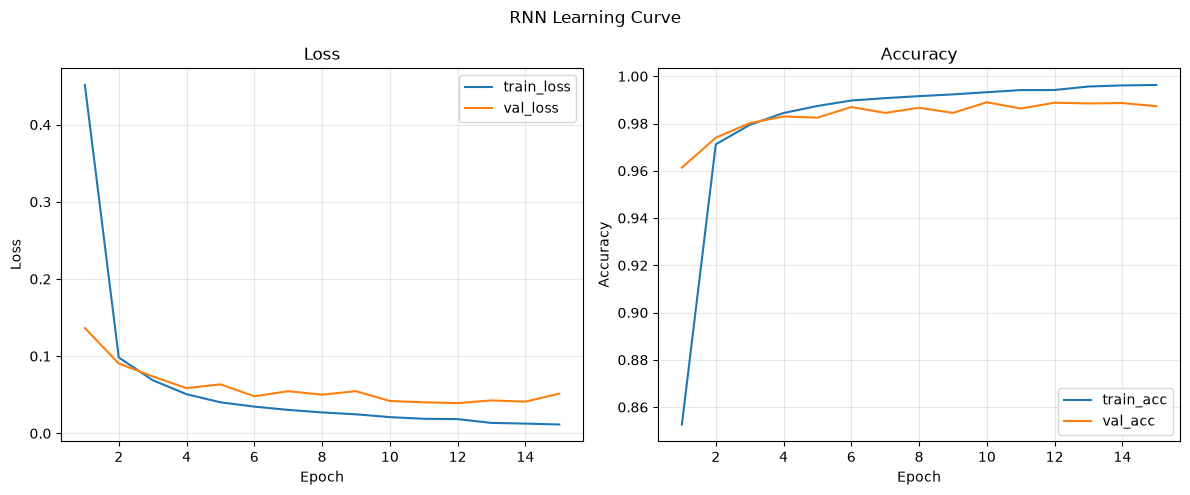

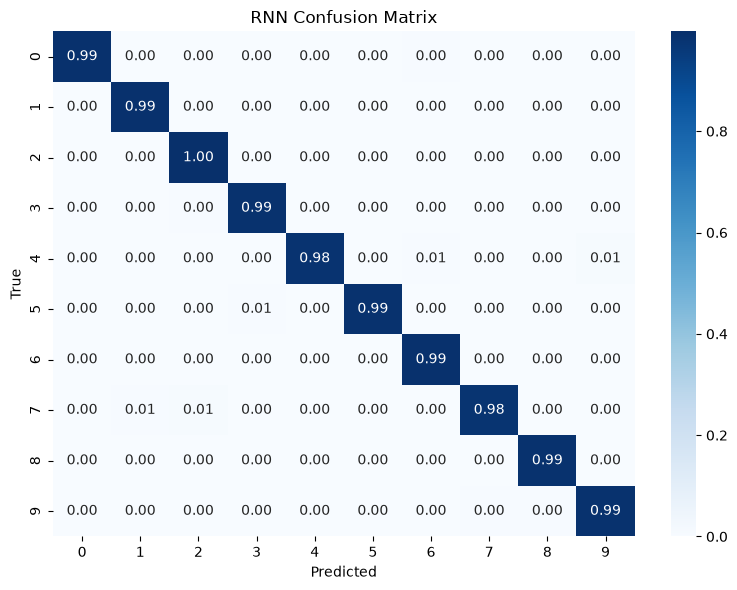

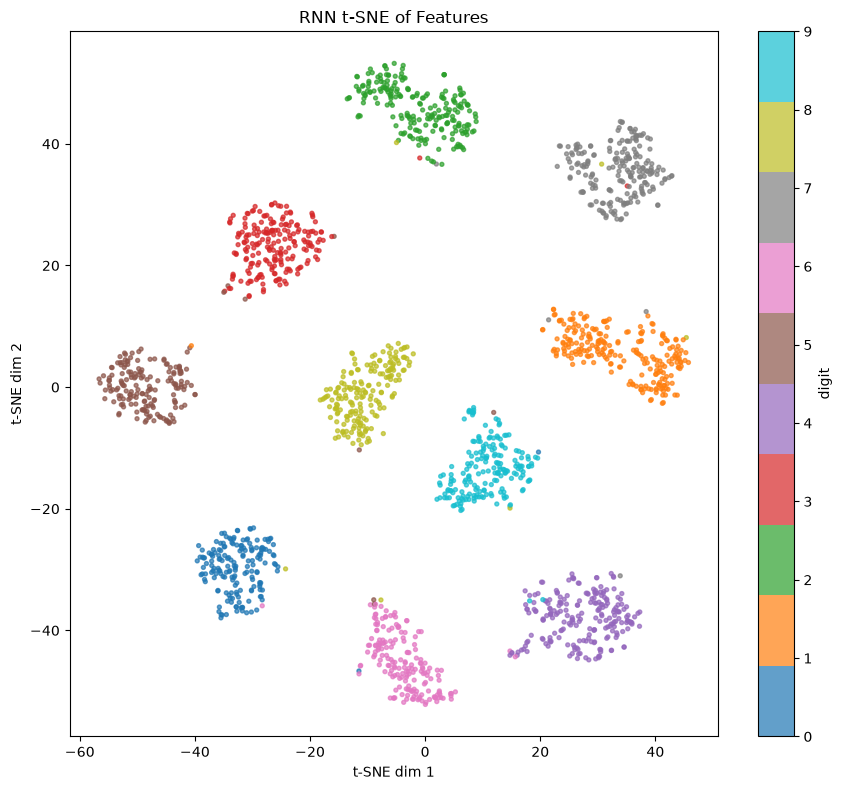

In [12]:
# RNN 시각화 3종
plot_learning_curve(rnn_history, title="RNN Learning Curve")

rnn_y_true, rnn_y_pred = collect_predictions(rnn_model, test_loader, device)
plot_confusion_matrix(rnn_y_true, rnn_y_pred, title="RNN Confusion Matrix", normalize=True)

rnn_features, rnn_labels = extract_features(rnn_model, test_loader, device, max_samples=2000)
plot_tsne(rnn_features, rnn_labels, title="RNN t-SNE of Features")

In [5]:
import time
from models.transformer import ViT

vit_model = ViT()
t0 = time.time()
vit_history, vit_best_epoch, vit_test_result = fit(
    vit_model, train_loader, val_loader, test_loader,
    epochs=15, device=device,
    save_path="../results/vit_best.pth"
)
vit_time = time.time() - t0
print(f"\n>> ViT 학습 시간: {vit_time:.1f}초")

NameError: name 'fit' is not defined

In [6]:
from utils.data import get_dataloaders
from utils.train import fit
from utils.metrics import collect_predictions, print_metrics_report, get_confusion_matrix
from utils.visualize import (
    plot_learning_curve,
    plot_confusion_matrix,
    extract_features,
    plot_tsne,
)
from models.mlp import MLP
from models.cnn import CNN
from models.rnn import RNN
from models.transformer import ViT

print("import 성공")

import 성공


In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=128, data_dir="../data"
)
print("device:", device, "| 데이터 로딩 완료")

device: cuda | 데이터 로딩 완료


In [8]:
import time
vit_model = ViT()
t0 = time.time()
vit_history, vit_best_epoch, vit_test_result = fit(
    vit_model, train_loader, val_loader, test_loader,
    epochs=15, device=device,
    save_path="../results/vit_best.pth"
)
vit_time = time.time() - t0
print(f"\n>> ViT 학습 시간: {vit_time:.1f}초")

Epoch  1/15 | train_loss 0.4020 acc 0.8734 | val_loss 0.1593 acc 0.9512  <- best
Epoch  2/15 | train_loss 0.1744 acc 0.9462 | val_loss 0.1273 acc 0.9610  <- best
Epoch  3/15 | train_loss 0.1466 acc 0.9537 | val_loss 0.1183 acc 0.9657  <- best
Epoch  4/15 | train_loss 0.1262 acc 0.9604 | val_loss 0.1031 acc 0.9678  <- best
Epoch  5/15 | train_loss 0.1153 acc 0.9632 | val_loss 0.0982 acc 0.9700  <- best
Epoch  6/15 | train_loss 0.1059 acc 0.9667 | val_loss 0.0956 acc 0.9713  <- best
Epoch  7/15 | train_loss 0.1035 acc 0.9666 | val_loss 0.0938 acc 0.9708  <- best
Epoch  8/15 | train_loss 0.0947 acc 0.9697 | val_loss 0.0868 acc 0.9710  <- best
Epoch  9/15 | train_loss 0.0937 acc 0.9696 | val_loss 0.0980 acc 0.9703
Epoch 10/15 | train_loss 0.0815 acc 0.9733 | val_loss 0.0888 acc 0.9750
Epoch 11/15 | train_loss 0.0821 acc 0.9741 | val_loss 0.0850 acc 0.9733  <- best
Epoch 12/15 | train_loss 0.0805 acc 0.9743 | val_loss 0.0854 acc 0.9740
Epoch 13/15 | train_loss 0.0790 acc 0.9745 | val_loss 0

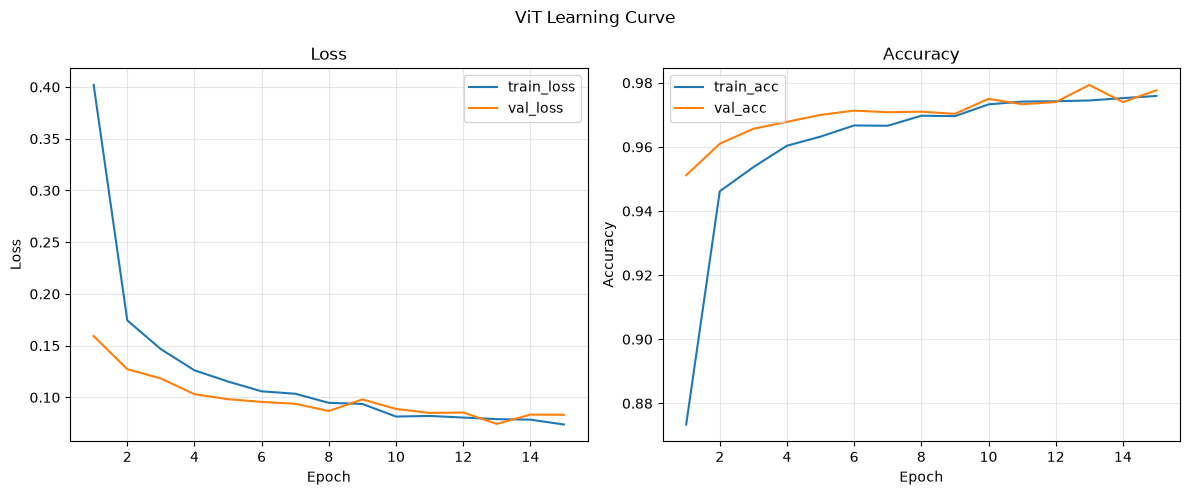

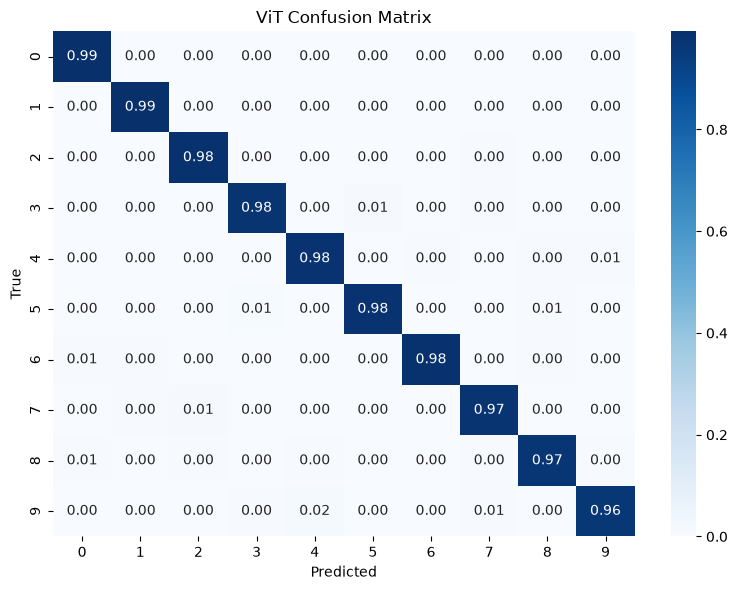

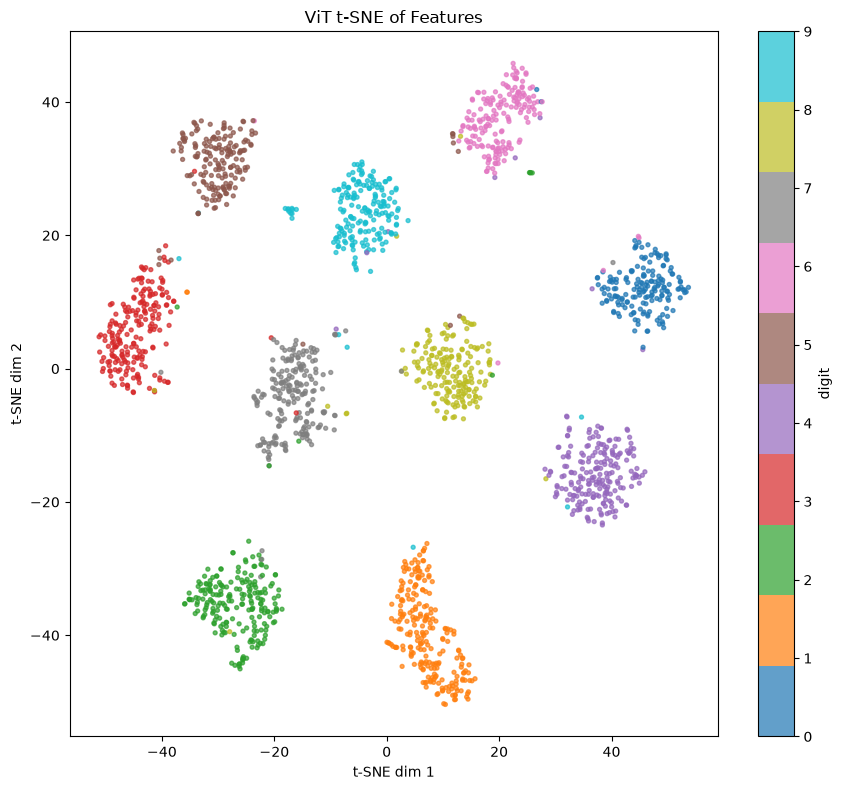

In [9]:
# ViT 시각화 3종
plot_learning_curve(vit_history, title="ViT Learning Curve")

vit_y_true, vit_y_pred = collect_predictions(vit_model, test_loader, device)
plot_confusion_matrix(vit_y_true, vit_y_pred, title="ViT Confusion Matrix", normalize=True)

vit_features, vit_labels = extract_features(vit_model, test_loader, device, max_samples=2000)
plot_tsne(vit_features, vit_labels, title="ViT t-SNE of Features")

In [10]:
import json

# 4모델 결과를 하나의 딕셔너리로 정리
all_results = {
    "MLP": {"history": history,     "test_acc": test_result[1],     "params": sum(p.numel() for p in MLP().parameters())},
    "CNN": {"history": cnn_history, "test_acc": cnn_test_result[1], "params": sum(p.numel() for p in CNN().parameters())},
    "RNN": {"history": rnn_history, "test_acc": rnn_test_result[1], "params": sum(p.numel() for p in RNN().parameters())},
    "ViT": {"history": vit_history, "test_acc": vit_test_result[1], "params": sum(p.numel() for p in ViT().parameters())},
}

# 파일로 저장 (json - 사람이 읽을 수 있음)
with open("../results/all_results.json", "w") as f:
    json.dump(all_results, f, indent=2)

print("저장 완료: ../results/all_results.json")
for name, r in all_results.items():
    print(f"  {name}: test_acc={r['test_acc']:.4f}, params={r['params']:,}")

NameError: name 'history' is not defined

In [11]:
print("history 있나:", 'history' in dir())
print("cnn_history 있나:", 'cnn_history' in dir())
print("rnn_history 있나:", 'rnn_history' in dir())
print("vit_history 있나:", 'vit_history' in dir())

history 있나: False
cnn_history 있나: False
rnn_history 있나: False
vit_history 있나: True


In [12]:
import time

# MLP/CNN/RNN 재학습 (변수명 통일: mlp_history)
print("=== MLP ===")
mlp_model = MLP()
mlp_history, mlp_best_epoch, mlp_test_result = fit(
    mlp_model, train_loader, val_loader, test_loader,
    epochs=15, device=device, save_path="../results/mlp_best.pth")

print("\n=== CNN ===")
cnn_model = CNN()
cnn_history, cnn_best_epoch, cnn_test_result = fit(
    cnn_model, train_loader, val_loader, test_loader,
    epochs=15, device=device, save_path="../results/cnn_best.pth")

print("\n=== RNN ===")
rnn_model = RNN()
rnn_history, rnn_best_epoch, rnn_test_result = fit(
    rnn_model, train_loader, val_loader, test_loader,
    epochs=15, device=device, save_path="../results/rnn_best.pth")

print("\n모두 완료")

=== MLP ===
Epoch  1/15 | train_loss 0.2840 acc 0.9154 | val_loss 0.1544 acc 0.9538  <- best
Epoch  2/15 | train_loss 0.1058 acc 0.9677 | val_loss 0.1172 acc 0.9647  <- best
Epoch  3/15 | train_loss 0.0718 acc 0.9772 | val_loss 0.0925 acc 0.9707  <- best
Epoch  4/15 | train_loss 0.0527 acc 0.9831 | val_loss 0.0904 acc 0.9750  <- best
Epoch  5/15 | train_loss 0.0420 acc 0.9858 | val_loss 0.0816 acc 0.9785  <- best
Epoch  6/15 | train_loss 0.0329 acc 0.9891 | val_loss 0.0797 acc 0.9773  <- best
Epoch  7/15 | train_loss 0.0236 acc 0.9922 | val_loss 0.0994 acc 0.9738
Epoch  8/15 | train_loss 0.0221 acc 0.9926 | val_loss 0.0909 acc 0.9763
Epoch  9/15 | train_loss 0.0207 acc 0.9929 | val_loss 0.0922 acc 0.9770
Epoch 10/15 | train_loss 0.0174 acc 0.9940 | val_loss 0.1073 acc 0.9747
Epoch 11/15 | train_loss 0.0195 acc 0.9930 | val_loss 0.0992 acc 0.9767
Epoch 12/15 | train_loss 0.0148 acc 0.9950 | val_loss 0.1015 acc 0.9782
Epoch 13/15 | train_loss 0.0136 acc 0.9955 | val_loss 0.1028 acc 0.977

In [13]:
import json

all_results = {
    "MLP": {"history": mlp_history, "test_acc": mlp_test_result[1], "params": sum(p.numel() for p in MLP().parameters())},
    "CNN": {"history": cnn_history, "test_acc": cnn_test_result[1], "params": sum(p.numel() for p in CNN().parameters())},
    "RNN": {"history": rnn_history, "test_acc": rnn_test_result[1], "params": sum(p.numel() for p in RNN().parameters())},
    "ViT": {"history": vit_history, "test_acc": vit_test_result[1], "params": sum(p.numel() for p in ViT().parameters())},
}

with open("../results/all_results.json", "w") as f:
    json.dump(all_results, f, indent=2)

print("저장 완료: ../results/all_results.json")
for name, r in all_results.items():
    print(f"  {name}: test_acc={r['test_acc']:.4f}, params={r['params']:,}")

저장 완료: ../results/all_results.json
  MLP: test_acc=0.9807, params=235,146
  CNN: test_acc=0.9897, params=421,642
  RNN: test_acc=0.9873, params=214,282
  ViT: test_acc=0.9793, params=274,954


In [14]:
with open("../results/all_results.json") as f:
    all_results = json.load(f)

In [15]:
for name, r in all_results.items():
    print(f"{name}: test_acc={r['test_acc']:.4f}, params={r['params']:,}")

MLP: test_acc=0.9807, params=235,146
CNN: test_acc=0.9897, params=421,642
RNN: test_acc=0.9873, params=214,282
ViT: test_acc=0.9793, params=274,954


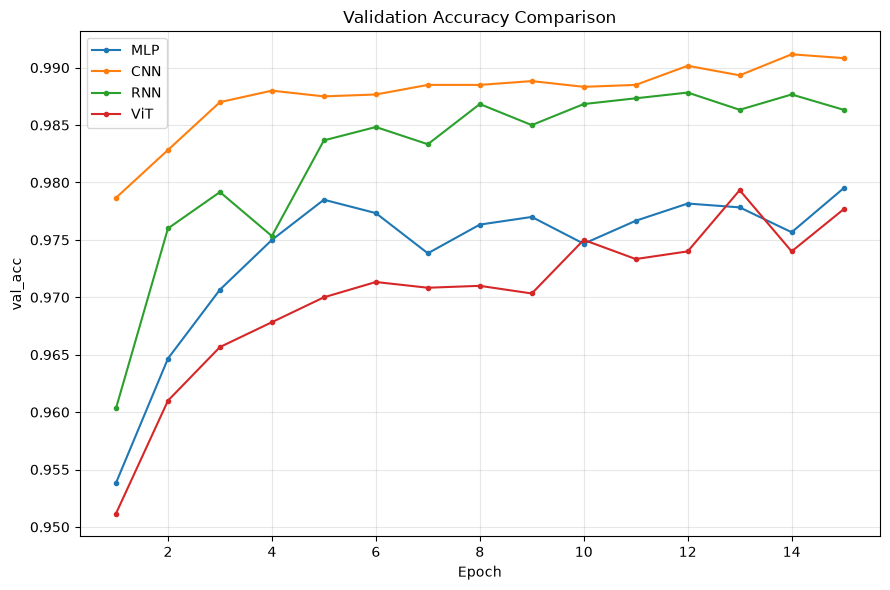

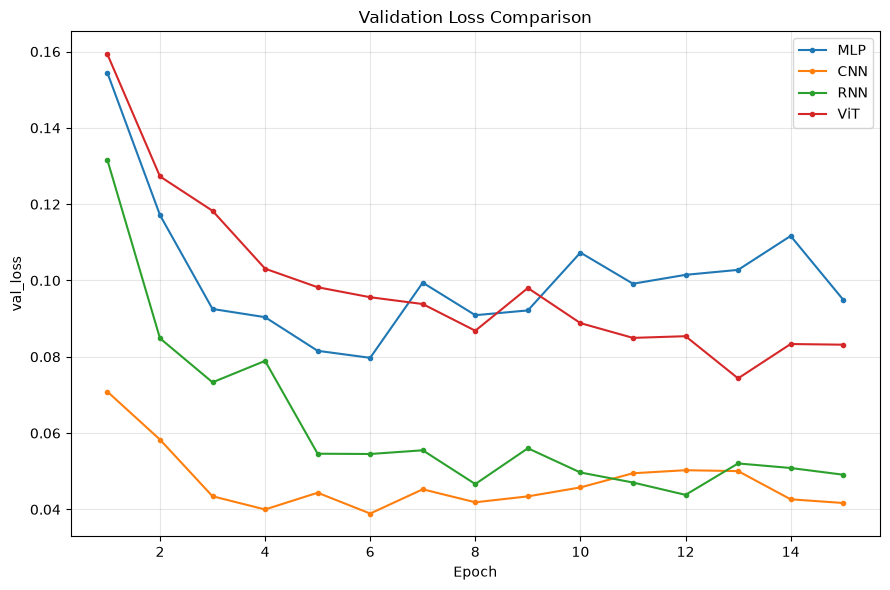

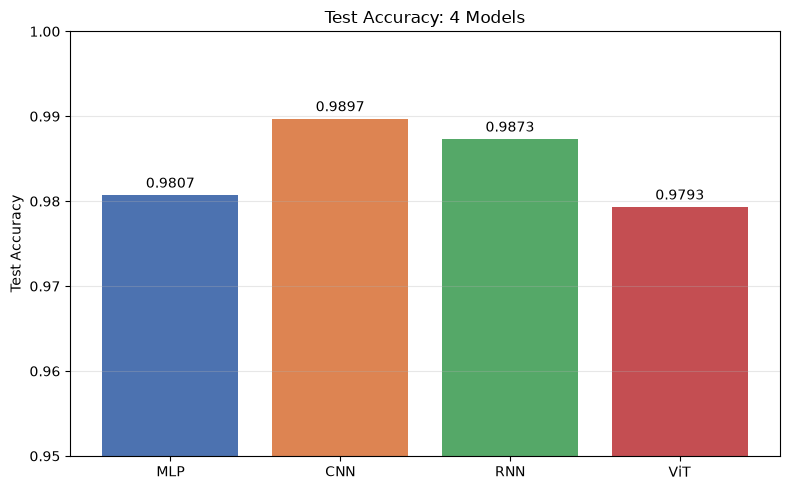

In [16]:
import importlib
import utils.visualize
importlib.reload(utils.visualize)
from utils.visualize import plot_model_comparison_curves, plot_accuracy_bar

# all_results에서 추출
all_hist = {name: r["history"] for name, r in all_results.items()}
all_acc  = {name: r["test_acc"] for name, r in all_results.items()}

# 1) val_acc 곡선 겹치기
plot_model_comparison_curves(all_hist, metric="val_acc",
    title="Validation Accuracy Comparison",
    save_path="../results/compare_val_acc.png")

# 2) val_loss 곡선 (수렴 속도)
plot_model_comparison_curves(all_hist, metric="val_loss",
    title="Validation Loss Comparison",
    save_path="../results/compare_val_loss.png")

# 3) 정확도 막대
plot_accuracy_bar(all_acc, title="Test Accuracy: 4 Models",
    save_path="../results/compare_accuracy.png")

In [20]:
import importlib
import utils.train, models.cnn
importlib.reload(utils.train)
importlib.reload(models.cnn)
from utils.train import fit, set_seed
from models.cnn import CNN            # 새 버전 CNN 다시 import

ablation_configs = {
    "Baseline":      dict(use_bn=False, use_dropout=False),
    "+BN":           dict(use_bn=True,  use_dropout=False),
    "+Dropout":      dict(use_bn=False, use_dropout=True),
    "+BN+Dropout":   dict(use_bn=True,  use_dropout=True),
}

ablation_results = {}

for name, cfg in ablation_configs.items():
    print(f"\n{'='*50}\n{name}: {cfg}\n{'='*50}")
    set_seed(42)
    model = CNN(**cfg)
    hist, best_ep, test_res = fit(
        model, train_loader, val_loader, test_loader,
        epochs=15, device=device,
        save_path=f"../results/cnn_{name.replace('+','').replace(' ','')}.pth"
    )
    ablation_results[name] = {
        "history": hist,
        "test_acc": test_res[1],
        "best_epoch": best_ep,
    }

print("\n\n=== Ablation 요약 ===")
for name, r in ablation_results.items():
    print(f"{name:15s}: test_acc={r['test_acc']:.4f}, best_epoch={r['best_epoch']}")


Baseline: {'use_bn': False, 'use_dropout': False}


Epoch  1/15 | train_loss 0.1882 acc 0.9428 | val_loss 0.0734 acc 0.9785  <- best
Epoch  2/15 | train_loss 0.0480 acc 0.9852 | val_loss 0.0500 acc 0.9865  <- best
Epoch  3/15 | train_loss 0.0331 acc 0.9897 | val_loss 0.0680 acc 0.9803
Epoch  4/15 | train_loss 0.0250 acc 0.9923 | val_loss 0.0461 acc 0.9863  <- best
Epoch  5/15 | train_loss 0.0184 acc 0.9945 | val_loss 0.0489 acc 0.9867
Epoch  6/15 | train_loss 0.0163 acc 0.9943 | val_loss 0.0431 acc 0.9883  <- best
Epoch  7/15 | train_loss 0.0108 acc 0.9968 | val_loss 0.0476 acc 0.9877
Epoch  8/15 | train_loss 0.0113 acc 0.9961 | val_loss 0.0474 acc 0.9875
Epoch  9/15 | train_loss 0.0090 acc 0.9972 | val_loss 0.0418 acc 0.9895  <- best
Epoch 10/15 | train_loss 0.0070 acc 0.9978 | val_loss 0.0414 acc 0.9900  <- best
Epoch 11/15 | train_loss 0.0067 acc 0.9981 | val_loss 0.0472 acc 0.9892
Epoch 12/15 | train_loss 0.0062 acc 0.9978 | val_loss 0.0549 acc 0.9892
Epoch 13/15 | train_loss 0.0068 acc 0.9976 | val_loss 0.0405 acc 0.9915  <- best
E

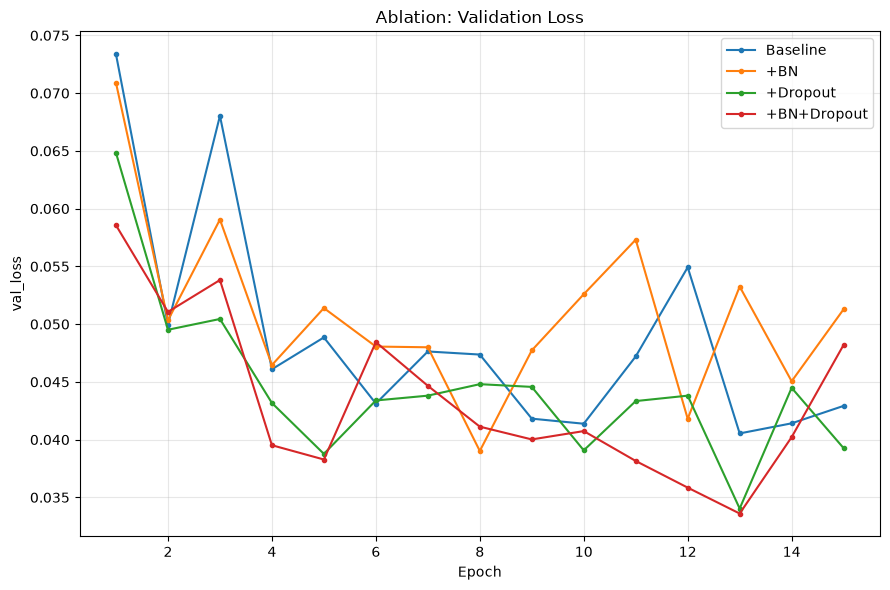

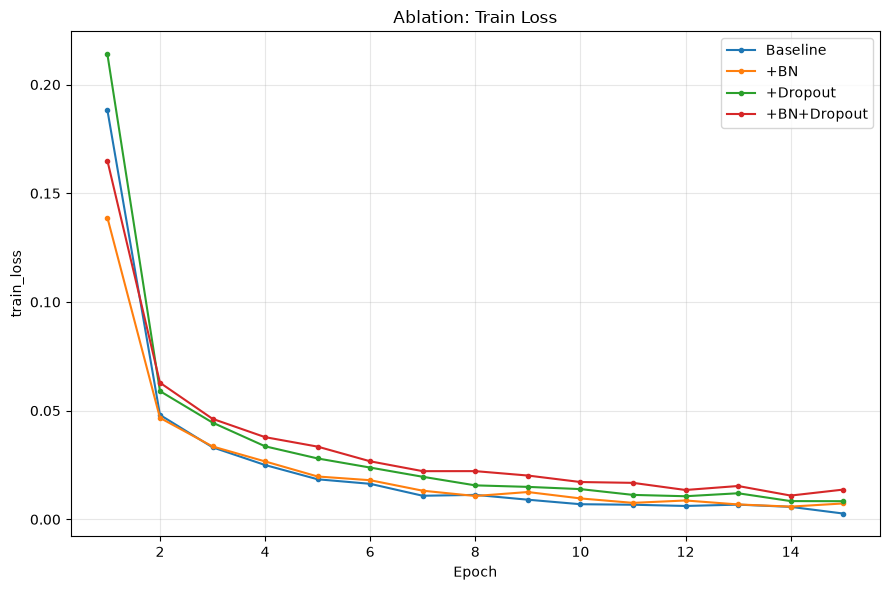

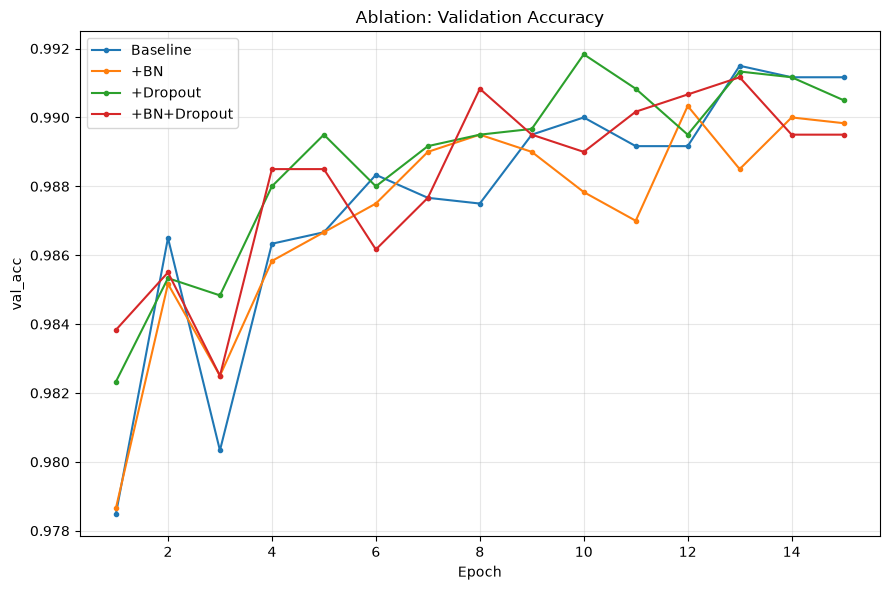

In [22]:
# ablation history들을 모아서 비교
ablation_hist = {name: r["history"] for name, r in ablation_results.items()}

# 1) val_loss — overfitting 완화가 여기 보임 (핵심)
plot_model_comparison_curves(ablation_hist, metric="val_loss",
    title="Ablation: Validation Loss",
    save_path="../results/ablation_val_loss.png")

# 2) train_loss — Dropout이 train을 덜 외우게 하는지
plot_model_comparison_curves(ablation_hist, metric="train_loss",
    title="Ablation: Train Loss",
    save_path="../results/ablation_train_loss.png")

# 3) val_acc
plot_model_comparison_curves(ablation_hist, metric="val_acc",
    title="Ablation: Validation Accuracy",
    save_path="../results/ablation_val_acc.png")

In [23]:
import importlib
import utils.data, utils.train, models.cnn
importlib.reload(utils.data)
importlib.reload(utils.train)
importlib.reload(models.cnn)
from utils.data import get_dataloaders
from utils.train import fit, set_seed
from models.cnn import CNN

# 축소 데이터 로더 (train 3000장만)
small_train_loader, val_loader_s, test_loader_s = get_dataloaders(
    batch_size=128, data_dir="../data", train_subset=3000
)
print(f"축소 train batch 수: {len(small_train_loader)}")   # 3000/128 ≈ 24

# 같은 4조합 ablation, 이번엔 축소 데이터로
ablation_configs = {
    "Baseline":    dict(use_bn=False, use_dropout=False),
    "+BN":         dict(use_bn=True,  use_dropout=False),
    "+Dropout":    dict(use_bn=False, use_dropout=True),
    "+BN+Dropout": dict(use_bn=True,  use_dropout=True),
}

ablation_small_results = {}

for name, cfg in ablation_configs.items():
    print(f"\n{'='*50}\n{name} (3000 samples): {cfg}\n{'='*50}")
    set_seed(42)
    model = CNN(**cfg)
    hist, best_ep, test_res = fit(
        model, small_train_loader, val_loader_s, test_loader_s,
        epochs=15, device=device,
        save_path=f"../results/cnn_small_{name.replace('+','').replace(' ','')}.pth"
    )
    ablation_small_results[name] = {
        "history": hist, "test_acc": test_res[1], "best_epoch": best_ep,
    }

print("\n\n=== 축소 데이터 Ablation 요약 (3000 samples) ===")
for name, r in ablation_small_results.items():
    print(f"{name:15s}: test_acc={r['test_acc']:.4f}, best_epoch={r['best_epoch']}")

축소 train batch 수: 24

Baseline (3000 samples): {'use_bn': False, 'use_dropout': False}
Epoch  1/15 | train_loss 1.1344 acc 0.6627 | val_loss 0.4621 acc 0.8543  <- best
Epoch  2/15 | train_loss 0.3274 acc 0.8937 | val_loss 0.2928 acc 0.9160  <- best
Epoch  3/15 | train_loss 0.2128 acc 0.9337 | val_loss 0.2250 acc 0.9310  <- best
Epoch  4/15 | train_loss 0.1522 acc 0.9567 | val_loss 0.1889 acc 0.9440  <- best
Epoch  5/15 | train_loss 0.0983 acc 0.9727 | val_loss 0.1538 acc 0.9535  <- best
Epoch  6/15 | train_loss 0.0702 acc 0.9780 | val_loss 0.1576 acc 0.9533
Epoch  7/15 | train_loss 0.0616 acc 0.9813 | val_loss 0.1483 acc 0.9578  <- best
Epoch  8/15 | train_loss 0.0479 acc 0.9860 | val_loss 0.1391 acc 0.9612  <- best
Epoch  9/15 | train_loss 0.0339 acc 0.9917 | val_loss 0.1273 acc 0.9653  <- best
Epoch 10/15 | train_loss 0.0281 acc 0.9943 | val_loss 0.1346 acc 0.9610
Epoch 11/15 | train_loss 0.0175 acc 0.9967 | val_loss 0.1316 acc 0.9617
Epoch 12/15 | train_loss 0.0133 acc 0.9977 | val_

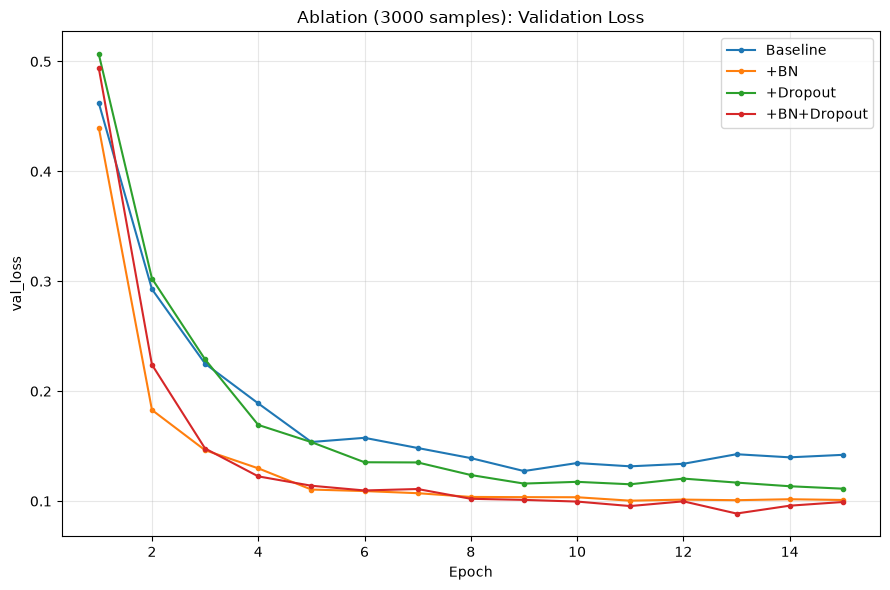

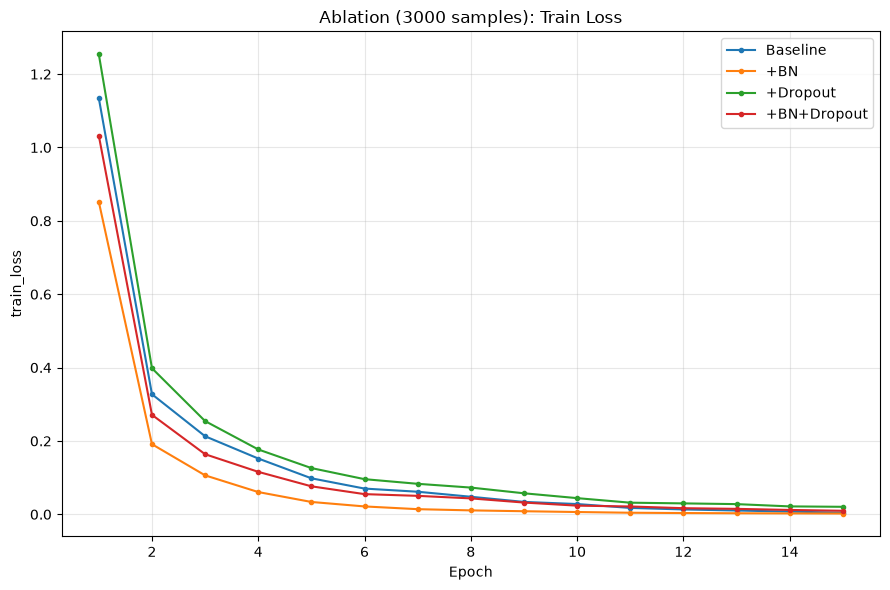

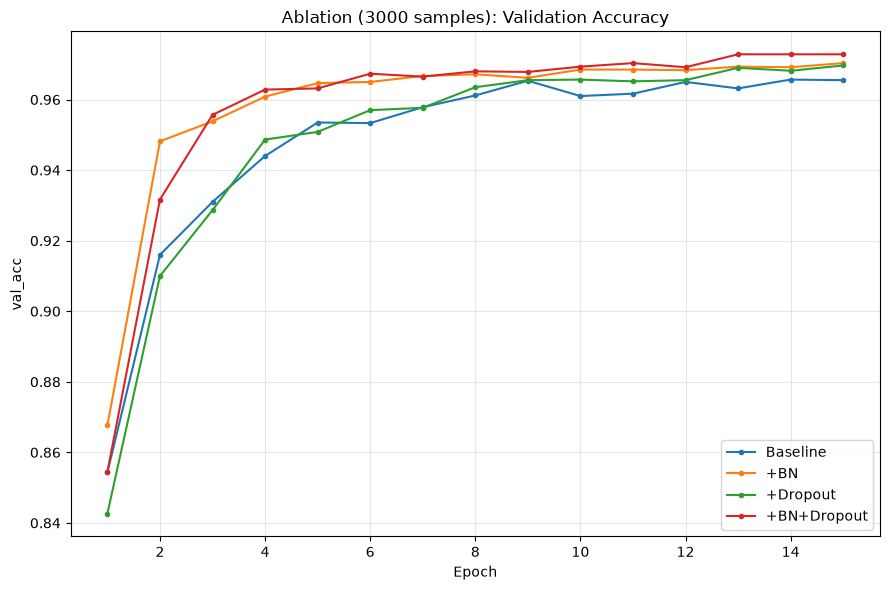

In [24]:
ablation_small_hist = {name: r["history"] for name, r in ablation_small_results.items()}

# val_loss — 이번엔 baseline overfitting이 뚜렷할 것
plot_model_comparison_curves(ablation_small_hist, metric="val_loss",
    title="Ablation (3000 samples): Validation Loss",
    save_path="../results/ablation_small_val_loss.png")

# train_loss — baseline이 0에 가깝게 외우는지
plot_model_comparison_curves(ablation_small_hist, metric="train_loss",
    title="Ablation (3000 samples): Train Loss",
    save_path="../results/ablation_small_train_loss.png")

# val_acc
plot_model_comparison_curves(ablation_small_hist, metric="val_acc",
    title="Ablation (3000 samples): Validation Accuracy",
    save_path="../results/ablation_small_val_acc.png")

In [25]:
import importlib
import utils.data
importlib.reload(utils.data)
from utils.data import get_dataloaders, get_transforms

# augment 옵션이 잘 작동하는지 간단 확인
train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=128, data_dir="../data", train_subset=3000, augment=True
)
print("augment 로더 생성 성공")
print(f"train batch: {len(train_loader)}, val batch: {len(val_loader)}, test batch: {len(test_loader)}")

augment 로더 생성 성공
train batch: 24, val batch: 47, test batch: 79


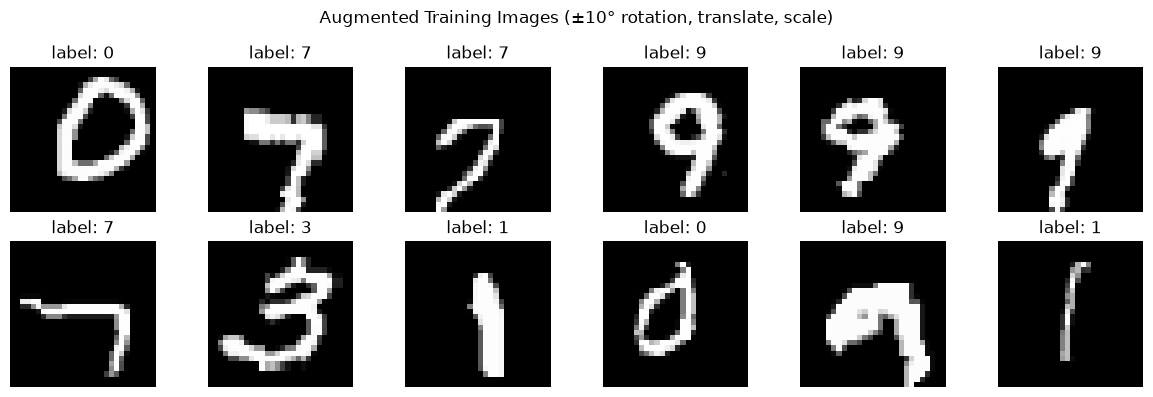

In [26]:
import matplotlib.pyplot as plt

# augment된 train_loader에서 한 배치 가져오기
aug_images, aug_labels = next(iter(train_loader))   # 위에서 만든 augment=True 로더

# 정규화 역변환 (보기 위해 원래 픽셀값으로)
def denorm(img):
    return img * 0.3081 + 0.1307   # Normalize 역산

# 12장 그리기
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i, ax in enumerate(axes.flat):
    img = denorm(aug_images[i]).squeeze().numpy()
    ax.imshow(img, cmap="gray")
    ax.set_title(f"label: {aug_labels[i].item()}")
    ax.axis("off")
plt.suptitle("Augmented Training Images (±10° rotation, translate, scale)")
plt.tight_layout()
plt.savefig("../results/augmentation_examples.png", dpi=150, bbox_inches="tight")
plt.show()

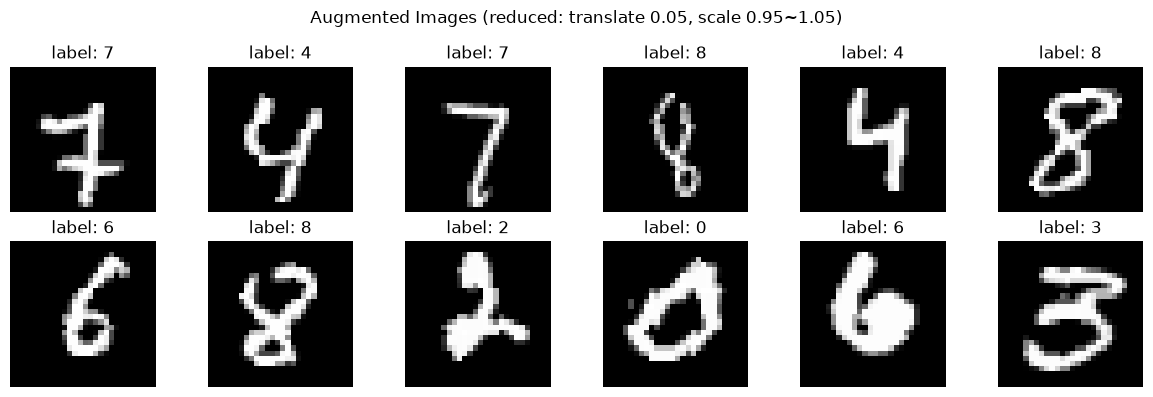

In [27]:
import importlib
import utils.data
importlib.reload(utils.data)
from utils.data import get_dataloaders

# 완화된 augment로 다시 로더 생성
train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=128, data_dir="../data", train_subset=3000, augment=True
)

# 다시 시각화 (같은 코드)
aug_images, aug_labels = next(iter(train_loader))
def denorm(img): return img * 0.3081 + 0.1307

fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i, ax in enumerate(axes.flat):
    img = denorm(aug_images[i]).squeeze().numpy()
    ax.imshow(img, cmap="gray")
    ax.set_title(f"label: {aug_labels[i].item()}")
    ax.axis("off")
plt.suptitle("Augmented Images (reduced: translate 0.05, scale 0.95~1.05)")
plt.tight_layout()
plt.savefig("../results/augmentation_examples.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
import importlib
import utils.data, utils.train, models.cnn
importlib.reload(utils.data); importlib.reload(utils.train); importlib.reload(models.cnn)
from utils.data import get_dataloaders
from utils.train import fit, set_seed
from models.cnn import CNN

# augment 적용된 축소 데이터 로더
aug_train_loader, aug_val_loader, aug_test_loader = get_dataloaders(
    batch_size=128, data_dir="../data", train_subset=3000, augment=True
)

# +All: BN + Dropout + Augmentation
print(f"\n{'='*50}\n+All (BN+Dropout+Aug, 3000 samples)\n{'='*50}")
set_seed(42)
model = CNN(use_bn=True, use_dropout=True)
all_hist, all_best_ep, all_test_res = fit(
    model, aug_train_loader, aug_val_loader, aug_test_loader,
    epochs=15, device=device,
    save_path="../results/cnn_small_All.pth"
)

# 기존 축소 ablation 결과에 +All 추가
ablation_small_results["+All"] = {
    "history": all_hist, "test_acc": all_test_res[1], "best_epoch": all_best_ep,
}

print("\n\n=== 축소 데이터 Ablation 최종 요약 (3000 samples) ===")
for name, r in ablation_small_results.items():
    print(f"{name:15s}: test_acc={r['test_acc']:.4f}, best_epoch={r['best_epoch']}")


+All (BN+Dropout+Aug, 3000 samples)
Epoch  1/15 | train_loss 1.2964 acc 0.5757 | val_loss 0.5934 acc 0.8395  <- best
Epoch  2/15 | train_loss 0.4921 acc 0.8430 | val_loss 0.2315 acc 0.9352  <- best
Epoch  3/15 | train_loss 0.2968 acc 0.9133 | val_loss 0.1566 acc 0.9532  <- best
Epoch  4/15 | train_loss 0.2257 acc 0.9320 | val_loss 0.1259 acc 0.9645  <- best
Epoch  5/15 | train_loss 0.1789 acc 0.9440 | val_loss 0.1010 acc 0.9697  <- best
Epoch  6/15 | train_loss 0.1593 acc 0.9527 | val_loss 0.0954 acc 0.9713  <- best
Epoch  7/15 | train_loss 0.1458 acc 0.9557 | val_loss 0.0930 acc 0.9708  <- best
Epoch  8/15 | train_loss 0.1326 acc 0.9603 | val_loss 0.1140 acc 0.9640
Epoch  9/15 | train_loss 0.1255 acc 0.9607 | val_loss 0.0975 acc 0.9697
Epoch 10/15 | train_loss 0.1065 acc 0.9633 | val_loss 0.0865 acc 0.9732  <- best
Epoch 11/15 | train_loss 0.1138 acc 0.9657 | val_loss 0.0762 acc 0.9758  <- best
Epoch 12/15 | train_loss 0.0869 acc 0.9713 | val_loss 0.0712 acc 0.9787  <- best
Epoch 13/

In [29]:
import importlib
import utils.data, utils.train, models.cnn
importlib.reload(utils.data); importlib.reload(utils.train); importlib.reload(models.cnn)
from utils.data import get_dataloaders
from utils.train import fit, set_seed
from models.cnn import CNN

# augment 적용된 축소 데이터 로더
aug_train_loader, aug_val_loader, aug_test_loader = get_dataloaders(
    batch_size=128, data_dir="../data", train_subset=3000, augment=True
)

# +All: BN + Dropout + Augmentation
print(f"\n{'='*50}\n+All (BN+Dropout+Aug, 3000 samples)\n{'='*50}")
set_seed(42)
model = CNN(use_bn=True, use_dropout=True)
all_hist, all_best_ep, all_test_res = fit(
    model, aug_train_loader, aug_val_loader, aug_test_loader,
    epochs=15, device=device,
    save_path="../results/cnn_small_All.pth"
)

# 기존 축소 ablation 결과에 +All 추가
ablation_small_results["+All"] = {
    "history": all_hist, "test_acc": all_test_res[1], "best_epoch": all_best_ep,
}

print("\n\n=== 축소 데이터 Ablation 최종 요약 (3000 samples) ===")
for name, r in ablation_small_results.items():
    print(f"{name:15s}: test_acc={r['test_acc']:.4f}, best_epoch={r['best_epoch']}")


+All (BN+Dropout+Aug, 3000 samples)
Epoch  1/15 | train_loss 1.2964 acc 0.5757 | val_loss 0.5933 acc 0.8400  <- best
Epoch  2/15 | train_loss 0.4921 acc 0.8430 | val_loss 0.2316 acc 0.9353  <- best
Epoch  3/15 | train_loss 0.2974 acc 0.9130 | val_loss 0.1579 acc 0.9530  <- best
Epoch  4/15 | train_loss 0.2263 acc 0.9327 | val_loss 0.1261 acc 0.9637  <- best
Epoch  5/15 | train_loss 0.1802 acc 0.9467 | val_loss 0.1002 acc 0.9700  <- best
Epoch  6/15 | train_loss 0.1574 acc 0.9527 | val_loss 0.0969 acc 0.9712  <- best
Epoch  7/15 | train_loss 0.1466 acc 0.9573 | val_loss 0.0926 acc 0.9715  <- best
Epoch  8/15 | train_loss 0.1334 acc 0.9583 | val_loss 0.1165 acc 0.9630
Epoch  9/15 | train_loss 0.1255 acc 0.9617 | val_loss 0.0971 acc 0.9698
Epoch 10/15 | train_loss 0.1053 acc 0.9643 | val_loss 0.0819 acc 0.9745  <- best
Epoch 11/15 | train_loss 0.1117 acc 0.9653 | val_loss 0.0755 acc 0.9752  <- best
Epoch 12/15 | train_loss 0.0847 acc 0.9713 | val_loss 0.0744 acc 0.9765  <- best
Epoch 13/

In [30]:
print("조합 개수:", len(ablation_small_results))
for name, r in ablation_small_results.items():
    print(f"{name:15s}: test_acc={r['test_acc']:.4f}")

조합 개수: 5
Baseline       : test_acc=0.9692
+BN            : test_acc=0.9728
+Dropout       : test_acc=0.9721
+BN+Dropout    : test_acc=0.9750
+All           : test_acc=0.9809


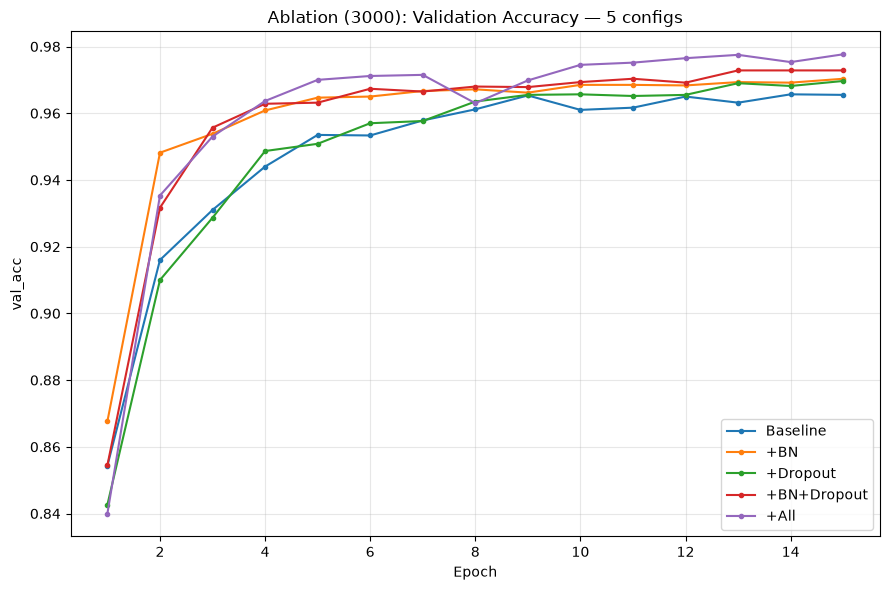

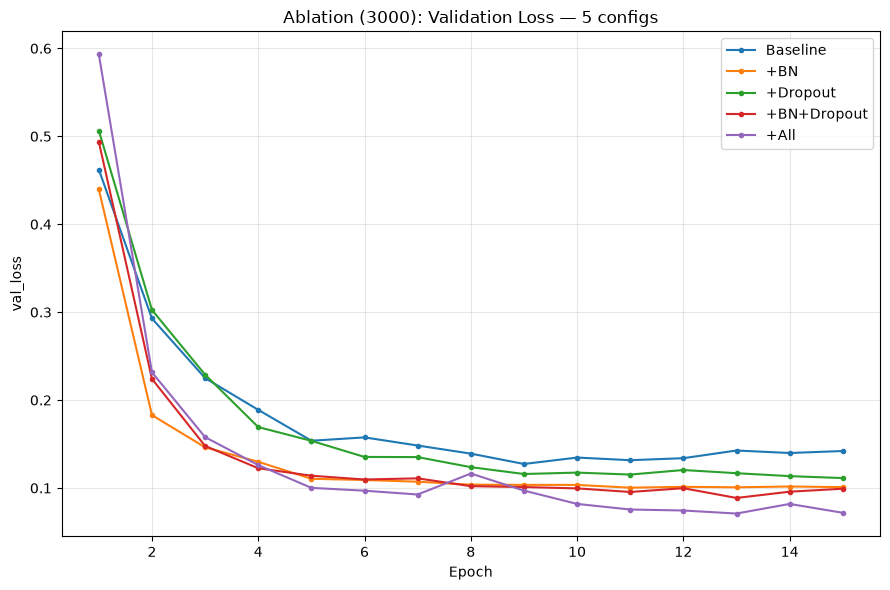

In [31]:
ablation_small_hist = {name: r["history"] for name, r in ablation_small_results.items()}

plot_model_comparison_curves(ablation_small_hist, metric="val_acc",
    title="Ablation (3000): Validation Accuracy — 5 configs",
    save_path="../results/ablation_small_final_valacc.png")

plot_model_comparison_curves(ablation_small_hist, metric="val_loss",
    title="Ablation (3000): Validation Loss — 5 configs",
    save_path="../results/ablation_small_final_valloss.png")

In [32]:
import json

# ablation 결과 저장 (전체 + 축소)
ablation_save = {
    "full_data": {name: {"test_acc": r["test_acc"], "best_epoch": r["best_epoch"], "history": r["history"]}
                  for name, r in ablation_results.items()},
    "small_data": {name: {"test_acc": r["test_acc"], "best_epoch": r["best_epoch"], "history": r["history"]}
                   for name, r in ablation_small_results.items()},
}
with open("../results/ablation_results.json", "w") as f:
    json.dump(ablation_save, f, indent=2)
print("ablation 결과 저장 완료")

ablation 결과 저장 완료
